# `quantumhomogenize` — quantum homogenization via fast inversion

Computational homogenization of a periodic two-phase elasticity cell on a
quantum computer. The operator is block-encoded by the companion package
[`pyblockencode`](https://github.com/UW-ERSL/PyBlockEncode); this package
preconditions it, establishes the conditioning results that follow, and reduces
the homogenized moduli to scalar quadratic forms in the resolvent.

The two-phase cell splits into a mean part and a contrast part (Equation 42 of
the block-encoding paper),

$$\mathbf{K}^{\chi} = \tfrac{E_1+E_2}{2}\,\mathbf{K} \;-\; \tfrac{E_1-E_2}{2}\sum_{(a,b)\in\mathcal{E}} R_{(a,b)}\mathbf{T}_{(a,b)}.$$

The mean part is block-circulant, so the QFT takes it to a $2\times 2$ symbol per
mode and it inverts in closed form: it is *fast invertible* in the sense of
Tong et al.

**Do not block-encode the inverse and compose.** $\|\mathbf{A}^{-1/2}\|$ grows
as $N$, so composing it with the contrast part inflates $\alpha$ by
$\kappa(\mathbf{A})\sim N^2$ and cancels the gain. Split the inverse square root
onto both sides instead:

$$\mathbf{M} = \mathbf{A}^{-1/2}\mathbf{K}^{\chi}\mathbf{A}^{-1/2} = V^{\dagger}\mathbf{E}V,
\qquad V = W^{1/2}G\mathbf{A}^{-1/2}.$$

Section 3 shows $\widehat V$ has unit singular values at every mode, which is why
$\alpha_{\mathbf{M}} = 1$.

In [1]:
import numpy as np
from quantumhomogenize import (
    symbol, symbol_inv_sqrt, square, square_t, oracle_cost,
    HYDROSTATIC, SHEAR, load, interior_dofs,
    bulk_shear, homogenized, spectrum, kappa,
    effective_interval_dense, PRECONDITIONER, encode)

np.set_printoptions(precision=6, suppress=True, linewidth=110)

Every size is set here, in qubits per direction $m$, so the grid is $N = 2^m$
and the operator has $2N^2$ degrees of freedom. Change these and re-run: every
table below follows.

In [2]:
M      = 3        # qubits per direction; N = 8, so 128 dofs
NU     = 0.3      # Poisson ratio
T      = 2        # half-gap of the centred square; side N - 2T
RHO    = 1e4      # contrast, stiff / compliant
EPS    = 1e-6     # target accuracy for the 1/x polynomial

E1, E2 = 1.0 / RHO, 1.0      # compliant inclusion, stiff connected matrix
chi    = square_t(M, T)
print(f"m = {M}, N = {2**M}, dofs = {2*4**M}, "
      f"v_f = {chi.mean():.4f}, rho = {RHO:.0e}")

m = 3, N = 8, dofs = 128, v_f = 0.2500, rho = 1e+04


## 1. The symbol

$\widehat{\mathbf{K}}(p,q)$ is the $2\times2$ acoustic tensor at mode $(p,q)$,
from the eigenvalues of $\mathbf{K}_{1D}$, $\mathbf{M}_{1D}$ and
$\mathbf{G}_{1D}$ substituted into Equations (15) to (17). It is real and
symmetric at every mode, positive definite off the zero mode, and both inverses
are rational in its entries plus two square roots:

$$\widehat{\mathbf{K}}^{-1/2} = \frac{1}{s\sqrt{t+2s}}\begin{pmatrix} d+s & -b \\ -b & a+s\end{pmatrix},\qquad s=\sqrt{\det},\; t=\operatorname{tr}.$$

No eigendecomposition, no iteration. That is Proposition 1.

In [3]:
from quantumhomogenize.fourier_symbol import mode_operator_matrix, reference

S = symbol(M, NU)
print("symbol shape:", S.shape, " (N, N, 2, 2)")
print("\nat mode (1,0):\n", S[1, 0])
print("\nat the zero mode (rigid translations):\n", S[0, 0])
print(f"\nsymbol vs element-by-element assembly: "
      f"{np.abs(mode_operator_matrix(S) - reference(M, NU)).max():.2e}")

symbol shape: (8, 8, 2, 2)  (N, N, 2, 2)

at mode (1,0):
 [[0.643721 0.      ]
 [0.       0.225302]]

at the zero mode (rigid translations):
 [[0. 0.]
 [0. 0.]]

symbol vs element-by-element assembly: 6.66e-16


The symbol reproduces a direct quadrature assembly to machine precision, and
vanishes at the zero mode where the two rigid translations live. Both inverses
are set to zero there, giving the pseudoinverse on the zero-mean subspace.

## 2. The load vanishes on phase-interior nodes

At a node whose four incident elements carry the same modulus, the four
contributions are the homogeneous-cell contributions scaled by one modulus, and
those sum to zero because a constant strain state is in equilibrium on a
periodic mesh. So $\mathbf{F}$ is supported on the phase interface,
**identically**, at every contrast and in both phases at once.

That is Proposition 4, and it is what leaves the compliant-phase interior modes
unexcited.

In [4]:
idx = interior_dofs(chi)
F   = load(M, chi, E1, E2, HYDROSTATIC)
F0  = load(M, chi, 1.0, 1.0, HYDROSTATIC)          # homogeneous cell

print(f"interior nodes: {len(idx)//2} of {4**M}")
print(f"max |F| at interior nodes : {np.abs(F[idx]).max():.2e}")
print(f"max |F| overall           : {np.abs(F).max():.6f}")
print(f"max |F|, homogeneous cell : {np.abs(F0).max():.2e}")

interior nodes: 48 of 64
max |F| at interior nodes : 1.39e-17
max |F| overall           : 0.178554
max |F|, homogeneous cell : 1.39e-17


## 3. The isometry

Writing $\mathbf{K}^\chi = G^\dagger W \mathbf{E} G$, the factor
$V = W^{1/2}G\mathbf{A}^{-1/2}$ has symbol
$\widehat V = \widehat G\,\widehat{\mathbf{K}}^{-1/2}$. If $V$ is an isometry
its norm carries no $N$, the symmetric product inherits no mesh dependence, and
the naive composition is ruled out. That is Proposition 2.

In [5]:
from quantumhomogenize.fastinvert import gradient_symbol, isometry_symbol

G = gradient_symbol(M, NU)
print("gradient symbol shape:", G.shape)
print("max |Ghat^dag Ghat - Khat| =",
      f"{np.abs(np.einsum('pqab,pqac->pqbc', G.conj(), G) - symbol(M, NU)).max():.2e}")

sv = np.linalg.svd(isometry_symbol(M, NU), compute_uv=False)
off0 = np.ones(sv.shape[:2], bool); off0[0, 0] = False
print(f"\nV singular values off the zero mode: "
      f"min {sv[off0].min():.10f}   max {sv[off0].max():.10f}")

gradient symbol shape: (8, 8, 12, 2)
max |Ghat^dag Ghat - Khat| = 1.78e-15

V singular values off the zero mode: min 1.0000000000   max 1.0000000000


## 4. The preconditioned operator

$\operatorname{spec}(\mathbf{M}) = [1/\rho,\,1]$ **exactly**, for every $\nu$,
every $N$ and every contrast, because
$E_{\min}\mathbf{K}\preceq\mathbf{K}^\chi\preceq E_{\max}\mathbf{K}$ in the
Loewner order and both ends are attained. The subnormalization is $1$ and the
condition number is the contrast alone: the mesh dependence is gone.
That is Proposition 3.

In [6]:
lam, U, Fp = spectrum(M, chi, E1, E2, NU)
nz = lam[lam > 1e-9 * lam.max()]
print(f"lam_min = {nz.min():.6e}   (1/rho = {1/RHO:.6e})")
print(f"lam_max = {nz.max():.6f}")
print(f"kappa   = {kappa(lam):.4f}   (rho = {RHO:.0f})")

from quantumhomogenize.macroload import stiffness
w = np.linalg.eigvalsh(stiffness(M, chi, E1, E2, NU))
w = w[w > 1e-9 * w.max()]
print(f"\nkappa(K^chi) unpreconditioned = {w.max()/w.min():.3e}")

lam_min = 1.000000e-04   (1/rho = 1.000000e-04)
lam_max = 1.000000
kappa   = 10000.0000   (rho = 10000)

kappa(K^chi) unpreconditioned = 4.866e+04


## 5. Effective conditioning

The worst case is the contrast, but it is attained only on modes the problem
never excites: Section 2 put the load on the interface, and the small
eigenvalues belong to displacements interior to the compliant phase. The
interval is defined by a budget on the *discarded weight*, which is the quantity
the degree argument needs.

In [7]:
from quantumhomogenize.precondition import discarded_weight

for name, col in (("hydrostatic", 0), ("shear", 1)):
    a, b = effective_interval_dense(lam, U, Fp[:, col])
    w_out, bias = discarded_weight(lam, U, Fp[:, col], a)
    print(f"{name:>12}: [{a:.4f}, {b:.4f}]  k_eff = {b/a:6.3f}   "
          f"w_out = {w_out:.1e}   bias/Q = {bias:.1e}")

print()
for delta in (1e-4, 1e-8, 1e-12):
    aa, bb = effective_interval_dense(lam, U, Fp[:, 0], delta)
    print(f"  delta = {delta:.0e}:  k_eff = {bb/aa:.4f}")

 hydrostatic: [0.3347, 1.0000]  k_eff =  2.988   w_out = 1.5e-26   bias/Q = 2.1e-26
       shear: [0.3172, 1.0000]  k_eff =  3.153   w_out = 3.1e-29   bias/Q = 3.7e-28

  delta = 1e-04:  k_eff = 2.9881
  delta = 1e-08:  k_eff = 2.9881
  delta = 1e-12:  k_eff = 2.9881


The discarded weight sits at the double-precision floor for a squared overlap,
$\sim10^{-30}$, and the endpoints do not move with the budget: there is a
genuine spectral gap.

**Caveat.** The orthogonality is *proved* only in the true-void limit, where the
supports are disjoint. At finite contrast it is measured, not proved.

## 6. The polynomial degree

A QSVT approximation to $1/x$ can be built on the effective interval rather than
the worst-case one. The base polynomial is `ChebIterPolynomial`, the closed-form
minimiser of the **relative** residual $\max|xp(x)-1|$, which is the criterion
this readout inherits since $Q=\sum_k w_k/\lambda_k$.

In [8]:
from quantumhomogenize.qspdegree import degree, achieved

a, b = effective_interval_dense(lam, U, Fp[:, 0])
d_worst, d_eff = degree(1.0 / kappa(lam), EPS), degree(a / b, EPS)
print(f"degree on [1/kappa, 1]           = {d_worst:>7}")
print(f"degree on the effective interval = {d_eff:>7}")
print(f"saving = {d_worst/d_eff:.1f}x       certificate = {achieved(d_eff, a/b):.2e}")

degree on [1/kappa, 1]           =  145087
degree on the effective interval =      41
saving = 3538.7x       certificate = 8.96e-07


## 7. The moduli

$\mathbf{C}^H = \mathbf{C}^{\rm Voigt} - |\Omega|^{-1}\mathbf{F}^{\mathsf T}(\mathbf{K}^\chi)^{+}\mathbf{F}$.
Contracting with a test strain collapses the correction to a single scalar, so
bulk and shear are each **one** quadratic form in the resolvent. The readout is
two scalars independent of $N$, and the $\xi$ parameter of Tong et al. never
enters because no solution state is prepared. That is Proposition 8.

In [9]:
KH, GH, ratio = bulk_shear(M, chi, RHO, NU)
C = homogenized(M, chi, E1, E2, NU)
print(f"K_H = {KH:.6f}   from the full tensor: {HYDROSTATIC @ C @ HYDROSTATIC / 4:.6f}")
print(f"G_H = {GH:.6f}   from the full tensor: {SHEAR @ C @ SHEAR:.6f}")
print(f"\ncorrection / modulus:  bulk {ratio[0]:.4f}   shear {ratio[1]:.4f}")

K_H = 0.349155   from the full tensor: 0.349155
G_H = 0.119001   from the full tensor: 0.119001

correction / modulus:  bulk 0.5344   shear 1.4241


The ratio is the precision amplification factor of the readout. It stays below
about $1.6$ up to contrast $100$ on a connected stiff phase.

**The stiff phase must be the connected one.** Putting the stiff phase in the
inclusion makes the connected phase vanishingly soft at high contrast, the
modulus collapses, and the correction dominates it. That is outside scope.

## 8. The preconditioner circuit

A QFT pair around a mode-multiplexed rotation. $\widehat{\mathbf{K}}^{-1/2}$ is
real symmetric, so it diagonalises in **one** rotation per mode:
$\theta=\tfrac12\operatorname{atan2}(2b,\,a-d)$ with the eigenvalues in closed
form. The displacement qubit carries $R(\theta)$, an ancilla carries the scale,
and $R(\theta)$ is undone. No dense unitary, no arithmetic.

In [10]:
qc, info = encode(PRECONDITIONER(nu=NU), m=M, materialize=True)
print(info)

PRECONDITIONER(nu=0.3)   N = 8 per direction   m = 3 qubits/direction   dofs = 128
  alpha  = 2.106769
  qubits = 8  (system 7, ancilla 1)
  CX = 280   depth = 531      [transpiled to ['cx', 'u']]
  verified: block vs symbol  2.22e-15
            V unit norm      5.55e-16
            OK = True


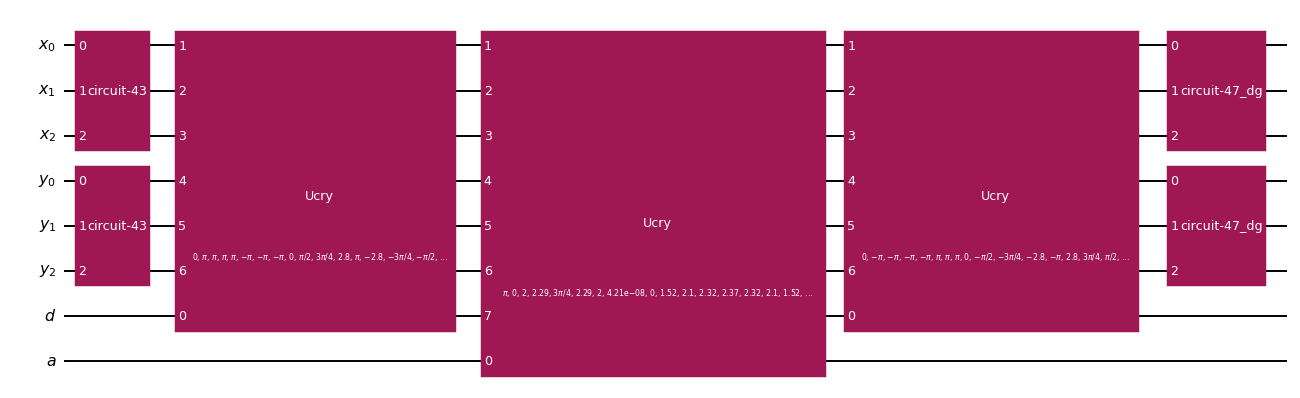

In [11]:
qc.draw("mpl", fold=-1, scale=0.7)

### 8.1 Cost

The multiplexers are exact but **dense**: one angle per mode, so CX grows as
$\mathcal{O}(N^2)$. The polylog claim needs a register-controlled symbol
preparation, an open assumption in the paper, not implemented here. These counts
are a correctness witness and an upper bound.

$\alpha$ doubles per mesh doubling, tracking $\|\mathbf{A}^{-1/2}\|\sim N$,
which is exactly why this encoding is never composed with
$U_{\mathbf{K}^\chi}$: the isometry $V$ carries no such factor.

In [12]:
print(f"{'m':>3} {'qubits':>7} {'alpha':>9} {'CX':>8} {'depth':>8}")
for m in (2, 3, 4, 5):
    _, i = encode(PRECONDITIONER(nu=NU), m=m)
    print(f"{m:>3} {i.qubits:>7} {i.alpha:>9.4f} {i.cx:>8} {i.depth:>8}")

  m  qubits     alpha       CX    depth
  2       6    1.1402       76      138
  3       8    2.1068      280      531
  4      10    4.1326     1072     2079


  5      12    8.2254     4176     8235


## 9. End to end

Precondition, apply $p(\mathbf{M})\approx\mathbf{M}^{-1}$ by QSVT, contract to
the modulus. The solver returns $f^{\mathsf T}p(\mathbf{M})f$ directly, so no
amplitude of the solution vector is ever read.

`fastsolve` uses a **dense** block encoding, which reintroduces the cost this
construction removes and caps at $m=4$.

In [13]:
import contextlib, io
from quantumhomogenize.fastsolve import solve_modulus

with contextlib.redirect_stdout(io.StringIO()):
    q, c, rel, d, p = solve_modulus(M, chi, 100.0, HYDROSTATIC, eps=1e-3)
print(f"degree {d},  quantum {q:.6f},  classical {c:.6f},  rel err {rel:.2e}")
print(f"success probability {p:.4f}")

degree 21,  quantum 0.721730,  classical 0.722009,  rel err 3.87e-04
success probability 0.3471


## 10. Scope

The centred square sweeps the void fraction continuously while keeping the
oracle flat in the mesh: the window $t\le e<N-t$ is a union of dyadic blocks,
each one multi-controlled gate, and the block count depends on $t/N$ rather than
on $m$.

In [14]:
print(f"{'v_f':>8}" + "".join(f"{'m='+str(m):>9}" for m in (4, 5, 6, 7)) + "   CX")
for vf in (0.25, 0.5625):
    row = f"{vf:>8.4f}"
    for m in (4, 5, 6, 7):
        N = 2**m
        t = int(round((N - N*np.sqrt(vf))/2))
        row += f"{oracle_cost(m, t)[1]:>9}"
    print(row)

     v_f      m=4      m=5      m=6      m=7   CX
  0.2500       54       54       54       54
  0.5625      150      150      150      150


## What is not established

1. **Polylog gate count.** The multiplexers are dense, $\mathcal{O}(N^2)$.
2. **Finite-contrast orthogonality.** Proved only in the true-void limit.
3. **$\kappa_{\rm eff}$ grows like $\log N$**, about $+0.39$ per doubling.
   Contrast independence holds; mesh independence does not.
4. **`fastsolve` uses a dense encoding**, so it caps at $m=4$.

See `README.md` for the full list.